# 09 Czysty pipeline modelowania dla `drop_10`

Ten notebook porządkuje wyniki po wyborze targetu `drop_10`. Celem nie jest jeszcze interpretacja modelu, tylko przygotowanie stabilnego, raportowalnego pipeline'u dla głównego targetu pracy.

Zakres:

- zbudowanie czystego datasetu modelowego dla `drop_10`, bez kolumn przyszłościowych użytych do konstrukcji etykiety,
- jawne rozdzielenie baseline'ów, głównych cech behawioralnych i wariantu diagnostycznego z bieżącym BWCI,
- ewaluacja temporal split oraz leave-one-user-out,
- zapis decyzji, który model przechodzi do interpretacji w kolejnym notebooku.


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT_CANDIDATES: list[Path] = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if (path / "AGENTS.md").exists()), Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "outputs"
VARIANTS_PATH = OUTPUT_DIR / "target_variants_event_threshold_10_v0_1.parquet"
SOURCE_METADATA_PATH = OUTPUT_DIR / "model_dataset_event_threshold_10_v0_1_metadata.json"
TARGET_DECISION_PATH = OUTPUT_DIR / "target_decision_event_threshold_10_v0_1.json"

CLEAN_DATASET_PATH = OUTPUT_DIR / "model_dataset_drop_10_v0_1.parquet"
CLEAN_METADATA_PATH = OUTPUT_DIR / "model_dataset_drop_10_v0_1_metadata.json"
TEMPORAL_RESULTS_PATH = OUTPUT_DIR / "final_model_results_drop_10_v0_1.csv"
LOGO_RESULTS_PATH = OUTPUT_DIR / "final_logo_results_drop_10_v0_1.csv"
LOGO_SUMMARY_PATH = OUTPUT_DIR / "final_logo_summary_drop_10_v0_1.csv"
MODEL_DECISION_PATH = OUTPUT_DIR / "final_model_decision_drop_10_v0_1.json"

TARGET_COL = "drop_10"
HORIZON = 10
DROP_THRESHOLD = -0.15
RANDOM_STATE = 42
THRESHOLD = 0.50
PRIMARY_METRIC = "auc_pr"

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 140)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Sekcja 1: Dane wejściowe i czysty dataset

`drop_10` oznacza zdarzenie, w którym przyszłe BWCI po horyzoncie 10 obserwacji jest niższe od bieżącego BWCI o co najmniej 0.15 punktu. To jest target zdarzeniowy: opisuje spadek ciągłości pracy, a nie sam niski poziom BWCI.

W tej sekcji usuwamy z datasetu kolumny przyszłościowe i alternatywne targety, żeby kolejne notebooki korzystały z jednej, bezpiecznej wersji danych modelowych.


In [2]:
if not VARIANTS_PATH.exists():
  raise FileNotFoundError(f"Missing target variants dataset: {VARIANTS_PATH}")
if not SOURCE_METADATA_PATH.exists():
  raise FileNotFoundError(f"Missing source metadata: {SOURCE_METADATA_PATH}")
if not TARGET_DECISION_PATH.exists():
  raise FileNotFoundError(f"Missing target decision: {TARGET_DECISION_PATH}")

source_dataset = pd.read_parquet(VARIANTS_PATH)
source_metadata = json.loads(SOURCE_METADATA_PATH.read_text())
target_decision = json.loads(TARGET_DECISION_PATH.read_text())
source_feature_sets: dict[str, list[str]] = source_metadata["feature_sets"]

feature_sets: dict[str, list[str]] = {
  "baseline_autoregressive": source_feature_sets["baseline_autoregressive"],
  "behavior_primary": source_feature_sets["behavior_primary"],
  "behavior_plus_bwci_diagnostic": source_feature_sets["behavior_plus_bwci"],
}

id_cols = ["USER", "obs_idx", "datetime", "temporal_split"]
all_feature_cols = sorted({feature for features in feature_sets.values() for feature in features})
clean_cols = id_cols + all_feature_cols + [TARGET_COL]
missing_cols = sorted(set(clean_cols) - set(source_dataset.columns))
if missing_cols:
  raise ValueError(f"Missing expected columns: {missing_cols}")

model_dataset = source_dataset[clean_cols].copy()
model_dataset["datetime"] = pd.to_datetime(model_dataset["datetime"])
model_dataset[TARGET_COL] = model_dataset[TARGET_COL].astype(int)

load_summary = pd.DataFrame(
  [
    {
      "rows": len(model_dataset),
      "users": model_dataset["USER"].nunique(),
      "target": TARGET_COL,
      "positive_rows": int(model_dataset[TARGET_COL].sum()),
      "positive_pct": model_dataset[TARGET_COL].mean() * 100,
      "horizon_rows": HORIZON,
      "drop_threshold": DROP_THRESHOLD,
      "source_recommendation": target_decision.get("recommended_primary_target"),
    }
  ]
)
load_summary


,rows,users,target,positive_rows,positive_pct,horizon_rows,drop_threshold,source_recommendation
0,76039,11,drop_10,11962,15.7314,10,-0.1500,drop_10


### Interpretacja danych wejściowych

Czysty dataset ma 76 039 obserwacji dla 11 użytkowników. Target `drop_10` ma 11 962 zdarzenia pozytywne, czyli 15.73% danych. To jest umiarkowanie niezbalansowany problem klasyfikacyjny, dlatego AUC-PR pozostaje główną metryką, a AUC-ROC traktujemy pomocniczo.

Ważna zmiana względem wcześniejszego `event_threshold_10`: w danych modelowych nie zostawiamy `BWCI_future_10`, `BWCI_future_delta_10` ani alternatywnych targetów. Te kolumny były potrzebne do audytu definicji etykiety, ale w czystym pipeline zwiększałyby ryzyko przypadkowego leakage.


In [3]:
split_summary = (
  model_dataset
  .groupby("temporal_split", observed=True)
  .agg(
    rows=(TARGET_COL, "size"),
    users=("USER", "nunique"),
    positive_rows=(TARGET_COL, "sum"),
    positive_pct=(TARGET_COL, lambda values: values.mean() * 100),
    start=("datetime", "min"),
    end=("datetime", "max"),
  )
  .reset_index()
  .sort_values("temporal_split")
)

user_summary = (
  model_dataset
  .groupby("USER")
  .agg(
    rows=(TARGET_COL, "size"),
    positive_rows=(TARGET_COL, "sum"),
    positive_pct=(TARGET_COL, lambda values: values.mean() * 100),
    start=("datetime", "min"),
    end=("datetime", "max"),
  )
  .reset_index()
  .sort_values("USER")
)

display(split_summary)
display(user_summary)


,temporal_split,rows,users,positive_rows,positive_pct,start,end
0,test,15212,11,2424,15.9348,2019-12-05 14:20:45.071,2020-01-14 09:43:38.352
1,train,45621,11,6845,15.0041,2019-11-20 12:08:51.669,2020-01-10 21:06:01.996
2,validation,15206,11,2693,17.7101,2019-12-03 15:22:00.529,2020-01-12 22:58:05.640


,USER,rows,positive_rows,positive_pct,start,end
0,0,5311,753,14.1781,2019-11-20 13:48:20.304,2020-01-11 17:56:54.223
1,1,13450,2800,20.8178,2019-12-04 22:13:01.785,2020-01-14 09:31:25.916
2,3,3136,473,15.0829,2019-12-09 14:53:22.760,2020-01-13 22:45:20.130
3,4,8110,1116,13.7608,2019-11-26 11:38:02.721,2020-01-14 09:03:05.426
4,5,1722,357,20.7317,2019-12-02 20:55:51.796,2019-12-05 23:29:48.556
5,6,982,151,15.3768,2019-12-18 21:44:51.449,2020-01-14 01:00:35.230
6,7,3557,540,15.1813,2019-12-04 08:58:00.932,2020-01-14 09:00:20.863
7,8,4280,547,12.7804,2019-11-20 12:09:14.895,2020-01-13 17:06:54.138
8,9,5745,722,12.5674,2019-11-20 14:34:28.657,2019-12-15 22:02:09.117
9,10,12921,2156,16.6860,2019-11-20 16:59:44.595,2020-01-14 09:43:19.013


### Interpretacja rozkładu targetu

Rozkład temporalny jest wystarczająco stabilny do raportowania: train ma 15.00% zdarzeń pozytywnych, validation 17.71%, a test 15.93%. Validation jest trochę wyższy, ale nie jest to przesunięcie takie jak przy poprzednim targetcie `event_threshold_10`.

Rozkład per użytkownik też jest używalny: najniższy udział zdarzeń ma User 9, 12.57%, a najwyższy User 1, 20.82%. To oznacza, że `drop_10` rozwiązuje główny problem z User 1 z poprzedniej definicji targetu, gdzie prawie nie było przypadków pozytywnych.


## Sekcja 2: Feature sety i kontrola leakage

Dzielimy cechy na trzy role:

- `baseline_autoregressive`: tylko bieżący `BWCI_pu`, mocny punkt odniesienia,
- `behavior_primary`: główny model behawioralny bez bieżącego BWCI i bez komponentów BWCI,
- `behavior_plus_bwci_diagnostic`: wariant diagnostyczny, nie główny dowód, bo zawiera bieżący BWCI.


In [4]:
def audit_feature_sets(feature_sets_to_check: dict[str, list[str]]) -> pd.DataFrame:
  """ Audit feature sets for obvious leakage and modeling role.

    Args:
      feature_sets_to_check: Mapping of feature set names to feature column names.

    Returns:
      pd.DataFrame: Feature set audit table.
  """
  leakage_markers = ["future", "target", "threshold", "drop", "rank"]
  rows: list[dict[str, object]] = []
  for feature_set_name, features in feature_sets_to_check.items():
    marker_features = [feature for feature in features if any(marker in feature.lower() for marker in leakage_markers)]
    bwci_features = [feature for feature in features if feature == "BWCI_pu" or feature.startswith("C_")]
    rows.append(
      {
        "feature_set": feature_set_name,
        "feature_count": len(features),
        "contains_future_or_target_marker": bool(marker_features),
        "marker_features": ", ".join(marker_features),
        "contains_current_bwci_or_components": bool(bwci_features),
        "bwci_related_features": ", ".join(bwci_features),
      }
    )
  return pd.DataFrame(rows)


feature_audit = audit_feature_sets(feature_sets)
feature_audit


,feature_set,feature_count,contains_future_or_target_marker,marker_features,contains_current_bwci_or_components,bwci_related_features
0,baseline_autoregressive,1,False,,True,BWCI_pu
1,behavior_primary,21,False,,False,
2,behavior_plus_bwci_diagnostic,22,False,,True,BWCI_pu


### Interpretacja feature setów

Główny zestaw `behavior_primary` ma 21 cech i nie zawiera ani targetu, ani kolumn przyszłościowych, ani bieżącego `BWCI_pu`. To jest właściwy zestaw do odpowiedzi na pytanie, czy z obserwowalnej telemetrii można przewidywać ryzyko przerwania ciągłości pracy.

`baseline_autoregressive` ma tylko 1 cechę, `BWCI_pu`, więc mierzy, ile daje sama informacja o bieżącym stanie indeksu. `behavior_plus_bwci_diagnostic` ma 22 cechy i zawiera `BWCI_pu`, dlatego zostaje wyłącznie wariantem diagnostycznym. Jeśli ten wariant wygrywa, nie traktujemy tego jako silniejszego dowodu wartości cech behawioralnych, tylko jako informację, że bieżący poziom BWCI jest predykcyjny dla przyszłego spadku.


## Sekcja 3: Modele i metryki

Porównujemy baseline'y z prostymi modelami głównymi. Nie stroimy jeszcze hiperparametrów, ponieważ celem 09 jest stabilizacja pipeline'u i wybór modelu do interpretacji, a nie maksymalizacja wyniku.


In [5]:
def make_scaled_logistic_pipeline(class_weight: str | None = "balanced") -> Pipeline:
  """ Create a median-imputed, scaled logistic regression pipeline.

    Args:
      class_weight: Class weighting strategy passed to LogisticRegression.

    Returns:
      Pipeline: Scikit-learn logistic regression pipeline.
  """
  return Pipeline(
    steps=[
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      ("model", LogisticRegression(max_iter=1000, class_weight=class_weight, random_state=RANDOM_STATE, solver="lbfgs")),
    ]
  )


def make_tree_imputer_pipeline(model: BaseEstimator) -> Pipeline:
  """ Create a median-imputed tree-model pipeline.

    Args:
      model: Scikit-learn tree-based classifier.

    Returns:
      Pipeline: Pipeline with median imputation and classifier.
  """
  return Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("model", model)])


models: dict[str, tuple[BaseEstimator, list[str], str]] = {
  "dummy_prior": (DummyClassifier(strategy="prior"), feature_sets["baseline_autoregressive"], "baseline"),
  "autoregressive_lr": (make_scaled_logistic_pipeline(), feature_sets["baseline_autoregressive"], "baseline"),
  "behavior_logistic_lr": (make_scaled_logistic_pipeline(), feature_sets["behavior_primary"], "primary"),
  "behavior_random_forest": (
    make_tree_imputer_pipeline(
      RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
      )
    ),
    feature_sets["behavior_primary"],
    "primary",
  ),
  "behavior_hist_gradient_boosting": (
    make_tree_imputer_pipeline(
      HistGradientBoostingClassifier(max_iter=120, learning_rate=0.06, l2_regularization=0.05, random_state=RANDOM_STATE)
    ),
    feature_sets["behavior_primary"],
    "primary",
  ),
  "behavior_plus_bwci_lr": (make_scaled_logistic_pipeline(), feature_sets["behavior_plus_bwci_diagnostic"], "diagnostic"),
}

model_inventory = pd.DataFrame(
  [{"model": name, "model_group": group, "feature_count": len(features)} for name, (_, features, group) in models.items()]
)
model_inventory


,model,model_group,feature_count
0,dummy_prior,baseline,1
1,autoregressive_lr,baseline,1
2,behavior_logistic_lr,primary,21
3,behavior_random_forest,primary,21
4,behavior_hist_gradient_boosting,primary,21
5,behavior_plus_bwci_lr,diagnostic,22


In [6]:
def get_xy(df: pd.DataFrame, features: list[str]) -> tuple[pd.DataFrame, pd.Series]:
  """ Extract features and target.

    Args:
      df: Modeling dataset.
      features: Feature column names.

    Returns:
      tuple[pd.DataFrame, pd.Series]: X and y.
  """
  return df[features], df[TARGET_COL].astype(int)


def predict_positive_probability(model: BaseEstimator, x_values: pd.DataFrame) -> np.ndarray:
  """ Predict positive-class probability from a fitted classifier.

    Args:
      model: Fitted classifier.
      x_values: Feature matrix.

    Returns:
      np.ndarray: Positive-class probabilities.
  """
  if hasattr(model, "predict_proba"):
    return model.predict_proba(x_values)[:, 1]
  decision = model.decision_function(x_values)
  return 1.0 / (1.0 + np.exp(-decision))


def score_predictions(y_true: pd.Series, y_proba: np.ndarray, threshold: float = THRESHOLD) -> dict[str, float]:
  """ Compute binary classification metrics.

    Args:
      y_true: Ground-truth binary labels.
      y_proba: Positive-class probabilities.
      threshold: Threshold used for hard labels.

    Returns:
      dict[str, float]: Metric dictionary.
  """
  y_true_arr = np.asarray(y_true).astype(int)
  y_pred = (y_proba >= threshold).astype(int)
  unique_classes = np.unique(y_true_arr)

  tp = int(((y_true_arr == 1) & (y_pred == 1)).sum())
  fp = int(((y_true_arr == 0) & (y_pred == 1)).sum())
  tn = int(((y_true_arr == 0) & (y_pred == 0)).sum())
  fn = int(((y_true_arr == 1) & (y_pred == 0)).sum())

  precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
  specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
  f1 = 2 * precision * recall / (precision + recall) if pd.notna(recall) and (precision + recall) > 0 else np.nan
  balanced = np.nanmean([recall, specificity]) if len(unique_classes) == 2 else np.nan

  return {
    "roc_auc": roc_auc_score(y_true_arr, y_proba) if len(unique_classes) == 2 else np.nan,
    "auc_pr": average_precision_score(y_true_arr, y_proba) if len(unique_classes) == 2 else np.nan,
    "brier": brier_score_loss(y_true_arr, y_proba),
    "balanced_accuracy": balanced,
    "precision_pos": precision,
    "recall_pos": recall,
    "f1_pos": f1,
    "predicted_positive_pct": y_pred.mean() * 100,
  }


### Interpretacja model inventory

Do raportowania zachowujemy sześć modeli. `dummy_prior` i `autoregressive_lr` są baseline'ami, trzy modele `behavior_*` są właściwym porównaniem modeli ML na cechach behawioralnych, a `behavior_plus_bwci_lr` jest wariantem diagnostycznym.

Taki układ odpowiada na dwa pytania naraz: czy model bije naiwny baseline oraz czy cechy behawioralne dodają coś ponad sam bieżący poziom BWCI.


## Sekcja 4: Temporal split

Temporal split ocenia predykcję przyszłych obserwacji w tym samym zbiorze użytkowników. To jest scenariusz łatwiejszy niż LOGO, ale najlepiej odpowiada typowemu użyciu modelu po zebraniu historii danego użytkownika.


In [7]:
train_df = model_dataset[model_dataset["temporal_split"] == "train"].copy()
validation_df = model_dataset[model_dataset["temporal_split"] == "validation"].copy()
test_df = model_dataset[model_dataset["temporal_split"] == "test"].copy()

fitted_temporal_models: dict[str, BaseEstimator] = {}
temporal_rows: list[dict[str, object]] = []
for model_name, (model, features, group) in models.items():
  fitted = clone(model)
  x_train, y_train = get_xy(train_df, features)
  fitted.fit(x_train, y_train)
  fitted_temporal_models[model_name] = fitted

  for split_name, eval_df in [("validation", validation_df), ("test", test_df)]:
    x_eval, y_eval = get_xy(eval_df, features)
    y_proba = predict_positive_probability(fitted, x_eval)
    temporal_rows.append(
      {
        "target": TARGET_COL,
        "model": model_name,
        "model_group": group,
        "split": split_name,
        "rows": len(eval_df),
        "positive_pct": y_eval.mean() * 100,
        **score_predictions(y_eval, y_proba),
      }
    )

temporal_results = pd.DataFrame(temporal_rows).sort_values(["split", PRIMARY_METRIC], ascending=[True, False])
temporal_results


,target,model,model_group,split,rows,positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
7,drop_10,behavior_random_forest,primary,test,15212,15.9348,0.8235,0.4111,0.1616,0.7489,0.3770,0.7248,0.4960,30.6403
9,drop_10,behavior_hist_gradient_boosting,primary,test,15212,15.9348,0.8206,0.4067,0.1113,0.5942,0.4807,0.2368,0.3173,7.8491
11,drop_10,behavior_plus_bwci_lr,diagnostic,test,15212,15.9348,0.8207,0.3898,0.1822,0.7576,0.3545,0.7867,0.4888,35.3602
3,drop_10,autoregressive_lr,baseline,test,15212,15.9348,0.8126,0.3689,0.1820,0.7529,0.3459,0.7884,0.4809,36.3134
5,drop_10,behavior_logistic_lr,primary,test,15212,15.9348,0.7377,0.2982,0.2141,0.6822,0.2757,0.7257,0.3996,41.9406
1,drop_10,dummy_prior,baseline,test,15212,15.9348,0.5000,0.1593,0.1340,0.5000,0.0000,0.0000,NaN,0.0000
6,drop_10,behavior_random_forest,primary,validation,15206,17.7101,0.8173,0.4690,0.1730,0.7373,0.3698,0.7494,0.4952,35.8871
8,drop_10,behavior_hist_gradient_boosting,primary,validation,15206,17.7101,0.8120,0.4253,0.1205,0.5752,0.4952,0.1927,0.2775,6.8920
10,drop_10,behavior_plus_bwci_lr,diagnostic,validation,15206,17.7101,0.8153,0.4114,0.1944,0.7570,0.3593,0.8340,0.5022,41.1088
2,drop_10,autoregressive_lr,baseline,validation,15206,17.7101,0.7889,0.3685,0.1968,0.7512,0.3493,0.8388,0.4932,42.5358


,target,model,model_group,split,rows,positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
0,drop_10,behavior_random_forest,primary,validation,15206,17.7101,0.8173,0.4690,0.1730,0.7373,0.3698,0.7494,0.4952,35.8871
1,drop_10,behavior_hist_gradient_boosting,primary,validation,15206,17.7101,0.8120,0.4253,0.1205,0.5752,0.4952,0.1927,0.2775,6.8920
2,drop_10,behavior_plus_bwci_lr,diagnostic,validation,15206,17.7101,0.8153,0.4114,0.1944,0.7570,0.3593,0.8340,0.5022,41.1088
3,drop_10,autoregressive_lr,baseline,validation,15206,17.7101,0.7889,0.3685,0.1968,0.7512,0.3493,0.8388,0.4932,42.5358
4,drop_10,behavior_logistic_lr,primary,validation,15206,17.7101,0.7202,0.3123,0.2367,0.6569,0.2630,0.7906,0.3947,53.2356
5,drop_10,dummy_prior,baseline,validation,15206,17.7101,0.5000,0.1771,0.1465,0.5000,0.0000,0.0000,NaN,0.0000


,target,model,model_group,split,rows,positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
0,drop_10,behavior_random_forest,primary,test,15212,15.9348,0.8235,0.4111,0.1616,0.7489,0.3770,0.7248,0.4960,30.6403
1,drop_10,behavior_hist_gradient_boosting,primary,test,15212,15.9348,0.8206,0.4067,0.1113,0.5942,0.4807,0.2368,0.3173,7.8491
2,drop_10,behavior_plus_bwci_lr,diagnostic,test,15212,15.9348,0.8207,0.3898,0.1822,0.7576,0.3545,0.7867,0.4888,35.3602
3,drop_10,autoregressive_lr,baseline,test,15212,15.9348,0.8126,0.3689,0.1820,0.7529,0.3459,0.7884,0.4809,36.3134
4,drop_10,behavior_logistic_lr,primary,test,15212,15.9348,0.7377,0.2982,0.2141,0.6822,0.2757,0.7257,0.3996,41.9406
5,drop_10,dummy_prior,baseline,test,15212,15.9348,0.5000,0.1593,0.1340,0.5000,0.0000,0.0000,NaN,0.0000


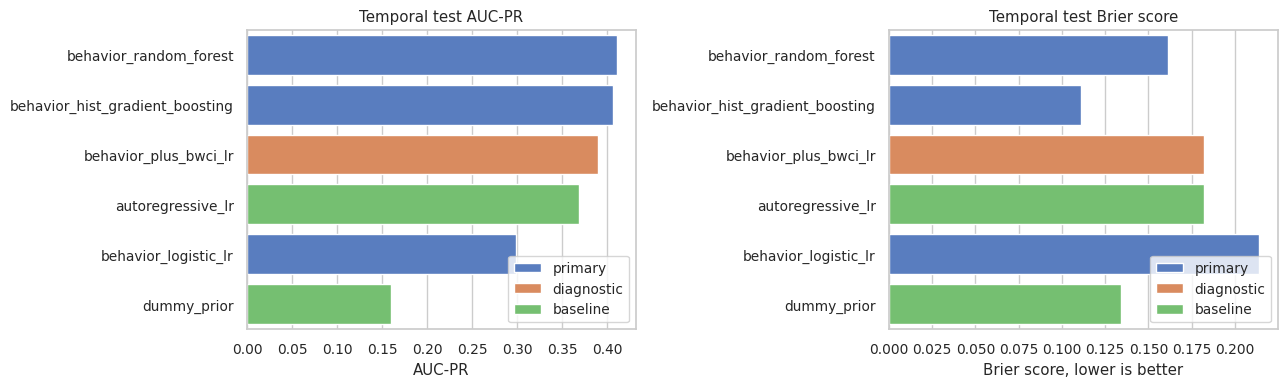

In [8]:
temporal_test = temporal_results[temporal_results["split"] == "test"].sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)
temporal_validation = temporal_results[temporal_results["split"] == "validation"].sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)

display(temporal_validation)
display(temporal_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=temporal_test, x="auc_pr", y="model", hue="model_group", dodge=False, ax=axes[0])
axes[0].set_title("Temporal test AUC-PR")
axes[0].set_xlabel("AUC-PR")
axes[0].set_ylabel("")
axes[0].legend(loc="lower right")

sns.barplot(data=temporal_test, x="brier", y="model", hue="model_group", dodge=False, ax=axes[1])
axes[1].set_title("Temporal test Brier score")
axes[1].set_xlabel("Brier score, lower is better")
axes[1].set_ylabel("")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()


### Interpretacja temporal split

Na teście temporalnym najlepszym modelem głównym jest `behavior_random_forest`: AUC-PR 0.4111, ROC-AUC 0.8235 i recall 0.7248. Model wyraźnie bije `dummy_prior` z AUC-PR 0.1593 oraz jest lepszy od `autoregressive_lr` z AUC-PR 0.3689 o 0.0421 punktu.

`behavior_hist_gradient_boosting` jest bardzo blisko w rankingu, AUC-PR 0.4067 i ROC-AUC 0.8206, ale przy progu 0.50 ma niski recall 0.2368. To oznacza, że dobrze porządkuje przypadki według ryzyka, ale jako klasyfikator progowy jest ostrożniejszy niż Random Forest.

Wariant diagnostyczny `behavior_plus_bwci_lr` osiąga AUC-PR 0.3898. Jest lepszy od samego autoregresyjnego baseline'u tylko nieznacznie, a zawiera bieżące BWCI, dlatego nie powinien zastępować głównego modelu behawioralnego w interpretacji.


## Sekcja 5: Leave-one-user-out

LOGO ocenia uogólnienie na użytkownika niewidzianego w treningu. To trudniejszy i metodologicznie ważniejszy test, ponieważ sprawdza, czy wzorce behawioralne są przenośne między osobami.


In [9]:
def evaluate_logo_fold(model_name: str, model: BaseEstimator, features: list[str], group: str, test_user: int) -> dict[str, object]:
  """ Evaluate one LOGO fold for one model.

    Args:
      model_name: Model identifier.
      model: Unfitted classifier.
      features: Feature columns.
      group: Model group label.
      test_user: Held-out user id.

    Returns:
      dict[str, object]: Fold-level metrics.
  """
  train_part = model_dataset[model_dataset["USER"] != test_user]
  test_part = model_dataset[model_dataset["USER"] == test_user]
  fitted = clone(model)
  x_train, y_train = get_xy(train_part, features)
  x_test, y_test = get_xy(test_part, features)
  fitted.fit(x_train, y_train)
  y_proba = predict_positive_probability(fitted, x_test)
  return {
    "target": TARGET_COL,
    "model": model_name,
    "model_group": group,
    "test_user": int(test_user),
    "train_rows": len(train_part),
    "test_rows": len(test_part),
    "test_positive_rows": int(y_test.sum()),
    "test_positive_pct": y_test.mean() * 100,
    **score_predictions(y_test, y_proba),
  }


logo_rows: list[dict[str, object]] = []
for user in sorted(model_dataset["USER"].unique()):
  for model_name, (model, features, group) in models.items():
    logo_rows.append(evaluate_logo_fold(model_name, model, features, group, int(user)))

logo_results = pd.DataFrame(logo_rows)
logo_results.sort_values(["test_user", PRIMARY_METRIC], ascending=[True, False]).head(36)


,target,model,model_group,test_user,train_rows,test_rows,test_positive_rows,test_positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
5,drop_10,behavior_plus_bwci_lr,diagnostic,0,70728,5311,753,14.1781,0.8053,0.3945,0.1761,0.7383,0.3158,0.7424,0.4431,33.3271
1,drop_10,autoregressive_lr,baseline,0,70728,5311,753,14.1781,0.7946,0.3622,0.1909,0.7063,0.2821,0.7118,0.4041,35.7748
3,drop_10,behavior_random_forest,primary,0,70728,5311,753,14.1781,0.7710,0.3321,0.1609,0.6742,0.2939,0.5777,0.3896,27.8667
2,drop_10,behavior_logistic_lr,primary,0,70728,5311,753,14.1781,0.7502,0.3194,0.2032,0.6647,0.2480,0.6600,0.3605,37.7330
4,drop_10,behavior_hist_gradient_boosting,primary,0,70728,5311,753,14.1781,0.7530,0.3190,0.1102,0.5183,0.4658,0.0452,0.0823,1.3745
0,drop_10,dummy_prior,baseline,0,70728,5311,753,14.1781,0.5000,0.1418,0.1220,0.5000,0.0000,0.0000,NaN,0.0000
7,drop_10,autoregressive_lr,baseline,1,62589,13450,2800,20.8178,0.7934,0.4019,0.1834,0.8111,0.4141,0.9907,0.5841,49.8067
11,drop_10,behavior_plus_bwci_lr,diagnostic,1,62589,13450,2800,20.8178,0.7863,0.3681,0.1880,0.7010,0.3841,0.6950,0.4948,37.6654
8,drop_10,behavior_logistic_lr,primary,1,62589,13450,2800,20.8178,0.6545,0.2607,0.1987,0.5005,0.2102,0.0821,0.1181,8.1338
10,drop_10,behavior_hist_gradient_boosting,primary,1,62589,13450,2800,20.8178,0.5898,0.2359,0.2041,0.5017,0.2315,0.0268,0.0480,2.4089


In [10]:
def weighted_nanmean(values: pd.Series, weights: pd.Series) -> float:
  """ Compute weighted mean while ignoring NaN values.

    Args:
      values: Values to average.
      weights: Non-negative weights.

    Returns:
      float: Weighted mean or NaN.
  """
  valid = values.notna()
  if not valid.any():
    return np.nan
  return float(np.average(values[valid], weights=weights[valid]))


def summarize_logo(results: pd.DataFrame) -> pd.DataFrame:
  """ Summarize LOGO fold metrics.

    Args:
      results: Fold-level LOGO metrics.

    Returns:
      pd.DataFrame: Model-level LOGO summary.
  """
  rows: list[dict[str, object]] = []
  metric_cols = ["roc_auc", "auc_pr", "brier", "balanced_accuracy", "precision_pos", "recall_pos", "f1_pos", "predicted_positive_pct"]
  for model_name, model_results in results.groupby("model"):
    row: dict[str, object] = {
      "target": TARGET_COL,
      "model": model_name,
      "model_group": model_results["model_group"].iloc[0],
      "folds": len(model_results),
      "valid_auc_folds": int(model_results["auc_pr"].notna().sum()),
      "total_test_rows": int(model_results["test_rows"].sum()),
      "weighted_positive_pct": weighted_nanmean(model_results["test_positive_pct"], model_results["test_rows"]),
    }
    for metric in metric_cols:
      row[f"{metric}_macro_mean"] = model_results[metric].mean(skipna=True)
      row[f"{metric}_weighted_mean"] = weighted_nanmean(model_results[metric], model_results["test_rows"])
    rows.append(row)
  return pd.DataFrame(rows)


logo_summary = summarize_logo(logo_results).sort_values("auc_pr_macro_mean", ascending=False).reset_index(drop=True)
logo_summary


,target,model,model_group,folds,valid_auc_folds,total_test_rows,weighted_positive_pct,roc_auc_macro_mean,roc_auc_weighted_mean,auc_pr_macro_mean,auc_pr_weighted_mean,brier_macro_mean,brier_weighted_mean,balanced_accuracy_macro_mean,balanced_accuracy_weighted_mean,precision_pos_macro_mean,precision_pos_weighted_mean,recall_pos_macro_mean,recall_pos_weighted_mean,f1_pos_macro_mean,f1_pos_weighted_mean,predicted_positive_pct_macro_mean,predicted_positive_pct_weighted_mean
0,drop_10,behavior_plus_bwci_lr,diagnostic,11,11,76039,15.7314,0.8103,0.8083,0.4113,0.3964,0.1696,0.1732,0.7260,0.7271,0.3428,0.3409,0.6973,0.7075,0.4558,0.4581,31.4551,32.3663
1,drop_10,autoregressive_lr,baseline,11,11,76039,15.7314,0.8066,0.8066,0.4033,0.3961,0.1866,0.1850,0.7367,0.7462,0.3225,0.3279,0.7676,0.7929,0.4529,0.4633,36.7988,37.8885
2,drop_10,behavior_random_forest,primary,11,11,76039,15.7314,0.7494,0.7162,0.3357,0.3084,0.1798,0.1847,0.6484,0.6336,0.3154,0.2977,0.5443,0.4995,0.3574,0.3319,29.2888,27.1821
3,drop_10,behavior_hist_gradient_boosting,primary,11,11,76039,15.7314,0.7544,0.7273,0.3344,0.3024,0.1256,0.1346,0.5436,0.5390,0.4146,0.3620,0.1262,0.1225,0.1618,0.1533,5.3003,5.6392
4,drop_10,behavior_logistic_lr,primary,11,11,76039,15.7314,0.7312,0.7173,0.3108,0.2918,0.2007,0.2124,0.6395,0.6199,0.2824,0.2638,0.5707,0.5345,0.3402,0.3073,33.4759,33.0501
5,drop_10,dummy_prior,baseline,11,11,76039,15.7314,0.5000,0.5000,0.1556,0.1573,0.1315,0.1329,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000


,target,model,model_group,test_user,train_rows,test_rows,test_positive_rows,test_positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
3,drop_10,behavior_random_forest,primary,0,70728,5311,753,14.1781,0.7710,0.3321,0.1609,0.6742,0.2939,0.5777,0.3896,27.8667
9,drop_10,behavior_random_forest,primary,1,62589,13450,2800,20.8178,0.4992,0.2080,0.2167,0.5033,0.2193,0.1025,0.1397,9.7323
15,drop_10,behavior_random_forest,primary,3,72903,3136,473,15.0829,0.8129,0.4265,0.2429,0.7177,0.2507,0.9281,0.3948,55.8355
21,drop_10,behavior_random_forest,primary,4,67929,8110,1116,13.7608,0.7792,0.3483,0.1167,0.6041,0.4521,0.2581,0.3286,7.8545
27,drop_10,behavior_random_forest,primary,5,74317,1722,357,20.7317,0.7676,0.4019,0.2245,0.6915,0.3271,0.8291,0.4691,52.5552
33,drop_10,behavior_random_forest,primary,6,75057,982,151,15.3768,0.7687,0.3402,0.2227,0.6985,0.2617,0.8146,0.3961,47.8615
39,drop_10,behavior_random_forest,primary,7,72482,3557,540,15.1813,0.7905,0.3751,0.1207,0.6101,0.4151,0.2944,0.3445,10.7675
45,drop_10,behavior_random_forest,primary,8,71759,4280,547,12.7804,0.7662,0.3132,0.1063,0.5901,0.3891,0.2340,0.2922,7.6869
51,drop_10,behavior_random_forest,primary,9,70294,5745,722,12.5674,0.8133,0.3370,0.1487,0.6864,0.3246,0.5319,0.4031,20.5918
57,drop_10,behavior_random_forest,primary,10,63118,12921,2156,16.6860,0.7341,0.3034,0.2059,0.6806,0.2995,0.6795,0.4158,37.8531


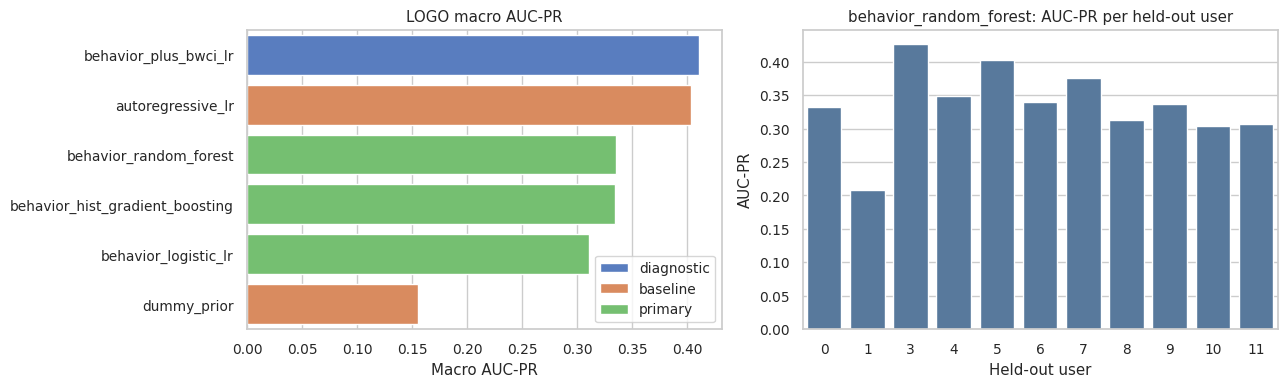

In [11]:
best_logo_primary = (
  logo_summary[logo_summary["model_group"] == "primary"]
  .sort_values("auc_pr_macro_mean", ascending=False)
  .iloc[0]
)
best_logo_primary_model = str(best_logo_primary["model"])
best_logo_primary_by_user = logo_results[logo_results["model"] == best_logo_primary_model].sort_values("test_user")

display(best_logo_primary_by_user)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=logo_summary, x="auc_pr_macro_mean", y="model", hue="model_group", dodge=False, ax=axes[0])
axes[0].set_title("LOGO macro AUC-PR")
axes[0].set_xlabel("Macro AUC-PR")
axes[0].set_ylabel("")
axes[0].legend(loc="lower right")

sns.barplot(data=best_logo_primary_by_user, x="test_user", y="auc_pr", ax=axes[1], color="#4C78A8")
axes[1].set_title(f"{best_logo_primary_model}: AUC-PR per held-out user")
axes[1].set_xlabel("Held-out user")
axes[1].set_ylabel("AUC-PR")
plt.tight_layout()
plt.show()


### Interpretacja LOGO

LOGO zmienia obraz wyników. Najlepszy model główny to nadal `behavior_random_forest`, ale jego macro AUC-PR wynosi 0.3357, a więc jest wyraźnie niższe niż 0.4111 w temporal split. To pokazuje, że część wzorca jest zależna od użytkownika.

Najmocniejszym punktem odniesienia w LOGO jest `autoregressive_lr` z macro AUC-PR 0.4033. Oznacza to, że sam bieżący poziom BWCI lepiej przenosi się między użytkownikami niż pełny zestaw cech behawioralnych. To nie unieważnia modelu behawioralnego, ale ogranicza interpretację: cechy telemetryczne przewidują `drop_10`, jednak ich przewaga jest mocniejsza w scenariuszu temporalnym niż w scenariuszu nowego użytkownika.

Dla `behavior_random_forest` najtrudniejszy jest User 1, AUC-PR 0.2080 i ROC-AUC 0.4992, czyli praktycznie brak rankingu ryzyka dla tego użytkownika. Najlepszy wynik jest dla User 3, AUC-PR 0.4265. To potwierdza, że w pracy trzeba raportować wyniki per użytkownik, a nie tylko wynik globalny.


## Sekcja 6: Decyzja modelowa i zapis artefaktów

Na podstawie temporal split oraz LOGO wybieramy model do interpretacji w notebooku 10. Kryterium nie jest wyłącznie najwyższy wynik, ale też rola modelu w pracy: interesuje nas model behawioralny bez bieżącego BWCI.


In [12]:
temporal_lookup = temporal_test.set_index("model")
logo_lookup = logo_summary.set_index("model")
selected_model = "behavior_random_forest"
selected_features = feature_sets["behavior_primary"]

model_decision: dict[str, object] = {
  "target": TARGET_COL,
  "target_definition": "Future BWCI_pu after 10 observations drops by at least 0.15 relative to current BWCI_pu.",
  "primary_metric": PRIMARY_METRIC,
  "selected_model": selected_model,
  "selected_feature_set": "behavior_primary",
  "selected_feature_count": len(selected_features),
  "temporal_test_auc_pr": float(temporal_lookup.loc[selected_model, "auc_pr"]),
  "temporal_test_roc_auc": float(temporal_lookup.loc[selected_model, "roc_auc"]),
  "temporal_test_brier": float(temporal_lookup.loc[selected_model, "brier"]),
  "temporal_delta_vs_dummy_auc_pr": float(temporal_lookup.loc[selected_model, "auc_pr"] - temporal_lookup.loc["dummy_prior", "auc_pr"]),
  "temporal_delta_vs_autoregressive_auc_pr": float(
    temporal_lookup.loc[selected_model, "auc_pr"] - temporal_lookup.loc["autoregressive_lr", "auc_pr"]
  ),
  "logo_macro_auc_pr": float(logo_lookup.loc[selected_model, "auc_pr_macro_mean"]),
  "logo_macro_roc_auc": float(logo_lookup.loc[selected_model, "roc_auc_macro_mean"]),
  "logo_delta_vs_dummy_auc_pr": float(logo_lookup.loc[selected_model, "auc_pr_macro_mean"] - logo_lookup.loc["dummy_prior", "auc_pr_macro_mean"]),
  "logo_delta_vs_autoregressive_auc_pr": float(
    logo_lookup.loc[selected_model, "auc_pr_macro_mean"] - logo_lookup.loc["autoregressive_lr", "auc_pr_macro_mean"]
  ),
  "main_limitation": "The selected behavioral model does not beat the autoregressive BWCI baseline under LOGO validation.",
  "next_notebook": "10_model_interpretation_drop_10",
}

reporting_summary = pd.DataFrame(
  [
    {
      "evaluation": "temporal_test",
      "selected_model_auc_pr": model_decision["temporal_test_auc_pr"],
      "dummy_auc_pr": float(temporal_lookup.loc["dummy_prior", "auc_pr"]),
      "autoregressive_auc_pr": float(temporal_lookup.loc["autoregressive_lr", "auc_pr"]),
      "delta_vs_dummy": model_decision["temporal_delta_vs_dummy_auc_pr"],
      "delta_vs_autoregressive": model_decision["temporal_delta_vs_autoregressive_auc_pr"],
    },
    {
      "evaluation": "logo_macro",
      "selected_model_auc_pr": model_decision["logo_macro_auc_pr"],
      "dummy_auc_pr": float(logo_lookup.loc["dummy_prior", "auc_pr_macro_mean"]),
      "autoregressive_auc_pr": float(logo_lookup.loc["autoregressive_lr", "auc_pr_macro_mean"]),
      "delta_vs_dummy": model_decision["logo_delta_vs_dummy_auc_pr"],
      "delta_vs_autoregressive": model_decision["logo_delta_vs_autoregressive_auc_pr"],
    },
  ]
)
reporting_summary


,evaluation,selected_model_auc_pr,dummy_auc_pr,autoregressive_auc_pr,delta_vs_dummy,delta_vs_autoregressive
0,temporal_test,0.4111,0.1593,0.3689,0.2517,0.0421
1,logo_macro,0.3357,0.1556,0.4033,0.1802,-0.0676


### Decyzja po notebooku 09

Do interpretacji przechodzi `behavior_random_forest` na zestawie `behavior_primary`. Decyzja jest pragmatyczna: to najlepszy model główny w temporal split, najlepszy lub remisujący model główny w LOGO i nie korzysta z bieżącego `BWCI_pu`, więc lepiej odpowiada celowi pracy niż wariant diagnostyczny.

Wynik trzeba jednak opisać ostrożnie. W temporal split model ma AUC-PR 0.4111 i przewagę 0.0421 nad `autoregressive_lr`, ale w LOGO ma macro AUC-PR 0.3357 i traci 0.0676 do `autoregressive_lr`. Wniosek do pracy: cechy behawioralne mają wartość predykcyjną dla przyszłego ryzyka spadku BWCI, lecz uogólnienie między użytkownikami jest ograniczone i autoregresyjny baseline pozostaje bardzo mocny.

Notebook 10 powinien więc interpretować `behavior_random_forest`, ale równolegle odnosić interpretację do tego ograniczenia. Nie powinniśmy przedstawiać modelu jako uniwersalnego predyktora dla nowych użytkowników bez dodatkowej adaptacji lub walidacji na własnych danych.


In [13]:
clean_metadata: dict[str, object] = {
  "dataset_version": "drop_10_v0.1",
  "source_dataset": str(VARIANTS_PATH.relative_to(PROJECT_ROOT)),
  "target": TARGET_COL,
  "target_definition": model_decision["target_definition"],
  "horizon_rows": HORIZON,
  "drop_threshold": DROP_THRESHOLD,
  "rows": len(model_dataset),
  "users": int(model_dataset["USER"].nunique()),
  "positive_rows": int(model_dataset[TARGET_COL].sum()),
  "positive_pct": float(model_dataset[TARGET_COL].mean() * 100),
  "feature_sets": feature_sets,
  "split_summary": split_summary.astype({"start": "str", "end": "str"}).to_dict(orient="records"),
  "user_summary": user_summary.astype({"start": "str", "end": "str"}).to_dict(orient="records"),
  "selected_model_decision": model_decision,
}

model_dataset.to_parquet(CLEAN_DATASET_PATH, index=False)
CLEAN_METADATA_PATH.write_text(json.dumps(clean_metadata, indent=2), encoding="utf-8")
temporal_results.to_csv(TEMPORAL_RESULTS_PATH, index=False)
logo_results.to_csv(LOGO_RESULTS_PATH, index=False)
logo_summary.to_csv(LOGO_SUMMARY_PATH, index=False)
MODEL_DECISION_PATH.write_text(json.dumps(model_decision, indent=2), encoding="utf-8")

print(f"Saved clean dataset: {CLEAN_DATASET_PATH}")
print(f"Saved clean metadata: {CLEAN_METADATA_PATH}")
print(f"Saved temporal results: {TEMPORAL_RESULTS_PATH}")
print(f"Saved LOGO results: {LOGO_RESULTS_PATH}")
print(f"Saved LOGO summary: {LOGO_SUMMARY_PATH}")
print(f"Saved model decision: {MODEL_DECISION_PATH}")


Saved clean dataset: /home/sefni/git/bwci-thesis/outputs/model_dataset_drop_10_v0_1.parquet
Saved clean metadata: /home/sefni/git/bwci-thesis/outputs/model_dataset_drop_10_v0_1_metadata.json
Saved temporal results: /home/sefni/git/bwci-thesis/outputs/final_model_results_drop_10_v0_1.csv
Saved LOGO results: /home/sefni/git/bwci-thesis/outputs/final_logo_results_drop_10_v0_1.csv
Saved LOGO summary: /home/sefni/git/bwci-thesis/outputs/final_logo_summary_drop_10_v0_1.csv
Saved model decision: /home/sefni/git/bwci-thesis/outputs/final_model_decision_drop_10_v0_1.json


## Krótkie sprawozdanie z etapu 09

Etap 09 zamyka przejście od audytu targetu do czystego modelowania. Przygotowano dataset `model_dataset_drop_10_v0_1.parquet`, który zawiera tylko identyfikatory, cechy dostępne w czasie `t` oraz target `drop_10`.

Najważniejszy wynik: `behavior_random_forest` jest najlepszym modelem głównym do dalszej interpretacji, ale jego przewaga nad baseline'em autoregresyjnym występuje w temporal split, nie w LOGO. To ustawia dalszy kierunek pracy: w notebooku 10 interpretujemy mechanizmy modelu behawioralnego, a potem w sensitivity notebook sprawdzamy, czy podobne wnioski pojawiają się dla alternatywnego targetu `threshold_le_full`.
